## LIME for time series

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def data_path(filename):
    return DATA_DIR / filename

def out_path(filename):
    return OUT_DIR / filename


**Objective:** In this session, we explore how to adapt and apply the LIME method to time series data.  
While the core idea of LIME remains the same, we will modify the way we define **interpretable features**, generate **perturbations** of the data, and compute **similarity** between time series.

In [1]:
! pip install ruptures

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ruptures: filename=ruptures-1.1.9-cp311-cp311-macosx_11_0_arm64.whl size=473129 sha256=65f7997b8b70d51474c5d56e40afc501de8b131ac6a71bc69e71f5592dc419da
  Stored in directory: /Users/romankochnev/Library/Caches/pip/wheels/91/4b/b2/08e23635050124c9dfc36d6a86ca63f025a8aa86c31a7e011d
Successfully built ruptures


In [2]:
! pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.6 MB/s eta 0:00:00a 0:00:01


In [3]:
! git clone https://github.com/TortySivill/LIMESegment.git
! pip3 install -r LIMESegment/requirements.txt

Cloning into 'LIMESegment'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 128 (delta 7), reused 6 (delta 5), pack-reused 109 (from 1)
Receiving objects: 100% (128/128), 27.09 MiB | 4.36 MiB/s, done.
Resolving deltas: 100% (46/46), done.
  Cloning https://github.com/TortySivill/complogic_colab (to revision 7a526ea9488d806aa9e98cb30f538ba1777d8c1a) to /private/var/folders/1h/rtxr723j3gn5xzc1q4yslr9w0000gn/T/pip-install-1gscbj6f/prolexa_4222111f9ffe42848c160d044d64ac9c
  Running command git clone --filter=blob:none --quiet https://github.com/TortySivill/complogic_colab /private/var/folders/1h/rtxr723j3gn5xzc1q4yslr9w0000gn/T/pip-install-1gscbj6f/prolexa_4222111f9ffe42848c160d044d64ac9c
  Running command git rev-parse -q --verify 'sha^7a526ea9488d806aa9e98cb30f538ba1777d8c1a'
  Running command git fetch -q https://github.com/TortySivill/complogic_colab 7a526ea9488d806aa9e98cb30f538ba177

In [51]:
#@title Python library imports go here and some utils
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import ruptures as rpt

import LIMESegment

from dtaidistance import dtw

from sklearn.linear_model import Ridge

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.cm as cm



# PyTorch dataset class
class ECG200Dataset(Dataset):
    def __init__(self, file_path):
        # Load data: first column is label (-1 or 1), rest are signal values
        data = np.loadtxt(file_path)
        labels = data[:, 0]
        signals = data[:, 1:]
        # Map labels to 0 and 1, instead of -1 and 1
        labels = np.where(labels == -1.0, 0, 1)
        self.signals = torch.tensor(signals, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return a single sample (signal, label)
        return self.signals[idx], self.labels[idx]


class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=(10, 20, 40), bottleneck_channels=32, use_bottleneck=True, dropout=0.2):
        super(InceptionBlock, self).__init__()
        self.use_bottleneck = use_bottleneck and in_channels > 1
        if self.use_bottleneck:
            self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        conv_in = bottleneck_channels if self.use_bottleneck else in_channels

        # Multi-scale convolution branches with padding='same' to preserve length
        self.branch_convs = nn.ModuleList([
            nn.Conv1d(conv_in, out_channels, kernel_size=k, padding='same', bias=False)
            for k in kernel_sizes
        ])
        # Pooling branch also preserves length
        self.branch_pool = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False)
        )

        self.batchnorm = nn.BatchNorm1d(out_channels * (len(kernel_sizes) + 1))
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        inp = x
        if self.use_bottleneck:
            x = self.bottleneck(x)
        branches = [self.dropout(self.activation(conv(x))) for conv in self.branch_convs]
        pool = self.branch_pool(inp)
        branches.append(self.dropout(self.activation(pool)))
        out = torch.cat(branches, dim=1)
        out = self.batchnorm(out)
        return out


class InceptionResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(InceptionResNetBlock, self).__init__()
        self.inception = InceptionBlock(in_channels, out_channels, **kwargs)
        total_channels = out_channels * (len(kwargs.get('kernel_sizes', (10,20,40))) + 1)
        self.residual_conv = (
            nn.Conv1d(in_channels, total_channels, kernel_size=1, bias=False)
            if in_channels != total_channels
            else None
        )
        self.bn = nn.BatchNorm1d(total_channels)
        self.activation = nn.ReLU()

    def forward(self, x):
        z = self.inception(x)
        res = x if self.residual_conv is None else self.residual_conv(x)
        z = z + res
        z = self.bn(z)
        return self.activation(z)


class InceptionTime(nn.Module):
    def __init__(self, num_blocks=3, in_channels=1, out_channels=32, num_classes=2,
                 kernel_sizes=(10,20,40), bottleneck_channels=32, dropout=0.2):
        super(InceptionTime, self).__init__()
        blocks = []
        channels = in_channels
        for _ in range(num_blocks):
            blocks.append(
                InceptionResNetBlock(
                    in_channels=channels,
                    out_channels=out_channels,
                    kernel_sizes=kernel_sizes,
                    bottleneck_channels=bottleneck_channels,
                    dropout=dropout,
                    use_bottleneck=True
                )
            )
            channels = out_channels * (len(kernel_sizes) + 1)
        self.features = nn.Sequential(*blocks)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x)

**Question 0:** The following describes a simple inference procedure for a CNN classifier model on [ECG200](https://www.timeseriesclassification.com/description.php?Dataset=ECG200). Experiment with it to understand its components, referring to the documentation as needed.

In [28]:
# Create datasets and loaders
BATCH_SIZE = 32
train_dataset = ECG200Dataset(data_path("ECG200_TRAIN.txt"))
test_dataset = ECG200Dataset(data_path("ECG200_TEST.txt"))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = InceptionTime(num_blocks=3, in_channels=1, out_channels=32, num_classes=2).to(device)
model.load_state_dict(torch.load(data_path("inception_time_ecg200.pth"), map_location=device))
model.eval()

# inference example
with torch.no_grad():
    batch_of_data = next(iter(test_loader))
    time_serie, label = batch_of_data
    time_serie, label = time_serie.to(device), label.to(device)

    # prediction on a batch of datapoints
    outputs = model(time_serie)
    _, predicted = torch.max(outputs.data, 1)

    print(f"Predicted labels: {predicted}")
    print(f"True labels: {label}")

Predicted labels: tensor([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
        1, 1, 0, 1, 0, 1, 1, 1])
True labels: tensor([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
        1, 1, 0, 1, 0, 1, 1, 1])


/var/folders/1h/rtxr723j3gn5xzc1q4yslr9w0000gn/T/ipykernel_48060/4146795725.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('inception_

**Question 1:** Use `rpt.Pelt(model="rbf").fit(x)` to generate a segmentation of the time serie `x` (use the data from Question 0). Plot it using `rpt.display()`, print it, and read the documentation!

In [153]:
signal = time_serie[0].cpu().numpy()
label_value = label[0].item()

algo = rpt.Pelt(model="rbf").fit(signal)
breakpoints = algo.predict(pen=10)

In [154]:
print("Breakpoints:", breakpoints)

Breakpoints: [40, 96]


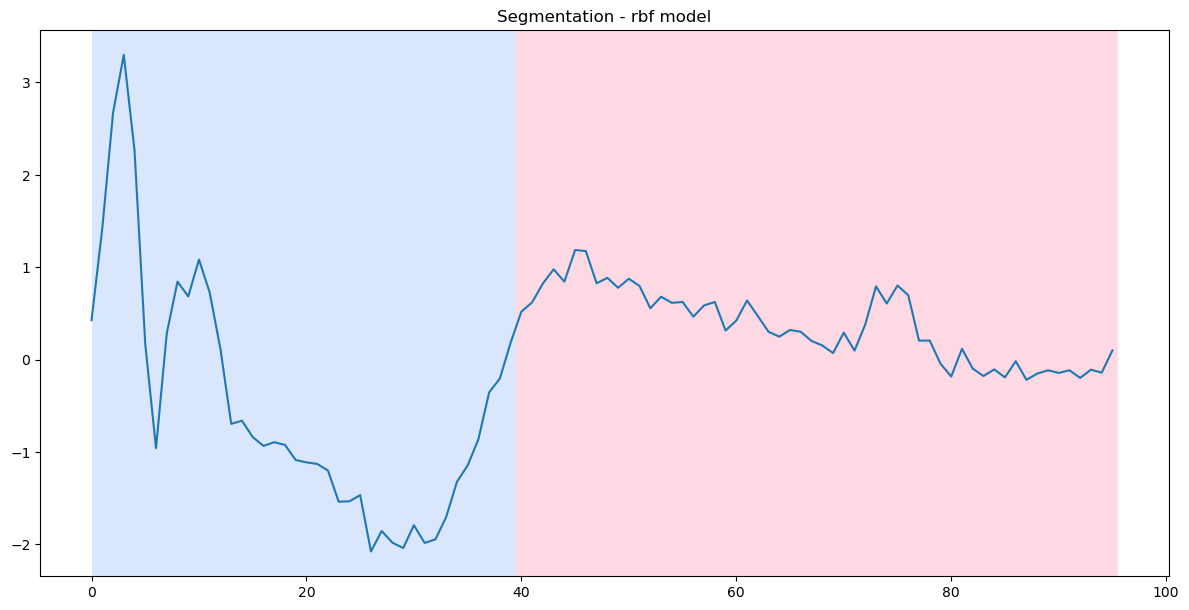

In [155]:
rpt.display(signal, breakpoints, figsize=(12, 6))
plt.title(f"Segmentation - rbf model")
plt.show()

**Question 1.bis:** Code a function `get_perturbations()` that generates $N=100$ perturbed versions of a time series.   
Each perturbation should correspond to the mean value of a segment of the time series. For more details, see lecture slides 153-154.

In [64]:
# HINT: use torch.randint to sample the perturbations vector

def get_perturbations(x, segments, N=100):
    T = len(x)
    d = len(segments)
    x = np.array(x)

    binary_matrix = torch.randint(0, 2, (N, d))
    perturbations = torch.zeros((N, T), dtype=torch.float32)

    for i in range(N):
        perturbed = x.copy()
        for j, (start, end) in enumerate(segments):
            if binary_matrix[i, j] == 0:
                perturbed[start:end] = np.mean(x[start:end])
        perturbations[i] = torch.tensor(perturbed, dtype=torch.float32)

    return perturbations, binary_matrix

**Question 2:** Code a function get_weights() which will compute the weights of the pertubated sample using Dynamic Time Warping (DTW) (use `dtw.distance(time_serie_not_perturbated, time_serie_perturbated)`). For more details, see lecture slide 155.

In [84]:
def get_weights(original_series, perturbed_list, nu=0.25):
    original_series = original_series.cpu().numpy() if torch.is_tensor(original_series) else original_series
    weights = []
    N = len(perturbed_list)
    
    for i in range(N):
        pert = perturbed_list[i].cpu().numpy() if torch.is_tensor(perturbed_list[i]) else perturbed_list[i]
        dist = dtw.distance(np.squeeze(original_series), np.squeeze(pert))
        weight = np.exp(- (dist ** 2) / (2 * nu ** 2))
        weights.append(weight)
    return torch.tensor(weights, dtype=torch.float32)

**Question 3:** Using the previous functions, implement the LIME algorithm as outlined in the lecture slide 146 to explain the predictions of the model on given a time series.

In [125]:
def lime_segment(model, x, boundaries, N=100, nu=0.25):
    x_np = x.cpu().numpy()
    segments = [(0 if i == 0 else boundaries[i - 1], boundaries[i])
                for i in range(len(boundaries))]

    # 1. Binary matrix Z
    d = len(segments)
    Z = torch.ones((N, d), dtype=torch.int64)

    # 2. Generate perturbations
    perturbed_signals = []
    for i in range(N):
        z_i = Z[i].clone()
        off_segments = torch.randperm(d)[:torch.randint(1, d + 1, (1,))].tolist()
        z_i[off_segments] = 0
        Z[i] = z_i

        perturbed = x.clone()
        for j in off_segments:
            a, b = segments[j]
            segment_mean = x[a:b].mean()
            perturbed[a:b] = segment_mean
        perturbed_signals.append(perturbed)

    perturbed_signals = torch.stack(perturbed_signals).to(device)

    # 3. Get predictions
    model.eval()
    with torch.no_grad():
        if perturbed_signals.ndim == 2:
            perturbed_signals = perturbed_signals.unsqueeze(1)
        preds = model(perturbed_signals)
        probs = torch.softmax(preds, dim=1)[:, 1].cpu().numpy()
#         print("Predicted probabilities (first 10):", probs[:10])

    # 4. Weights
    weights = get_weights(x_np, perturbed_signals, nu=nu).numpy()

    # 5. Fit a model
    ridge = Ridge(alpha=1.0)
    ridge.fit(Z.numpy(), probs, sample_weight=weights)

    return ridge.coef_

**Question 4:** Plot a heatmap for a given time series, using a color map based on the LIME coefficients of each segment.

In [ ]:
# HINT: use integer array indexing to generate the heatmap

def plot_lime_segments(x, boundaries, coefs, cmap_name='bwr'):
    if isinstance(x, torch.Tensor):
        x = x.cpu().numpy()

    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=min(coefs), vmax=max(coefs))

    segments = [(0 if i == 0 else boundaries[i - 1], boundaries[i])
                for i in range(len(boundaries))]

    plt.figure(figsize=(12, 3))
    for i, (a, b) in enumerate(segments):
        color = cmap(norm(coefs[i]))
        plt.plot(range(a, b), x[a:b], color=color, linewidth=2)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, label="LIME coefficient")
    plt.title("LIME Explanation")
    plt.xlabel("Time")
    plt.ylabel("Signal")
    plt.tight_layout()
    plt.savefig(out_path("lime_explanation.pdf"), dpi=300)
    plt.show()

In [77]:
print(type(model))

<class '__main__.InceptionTime'>


/var/folders/1h/rtxr723j3gn5xzc1q4yslr9w0000gn/T/ipykernel_48060/1380543130.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1h/rtxr723j3gn5xzc1q4yslr9w0000gn/T/ipykernel_48060/1380543130.py:20: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label="LIME coefficient")


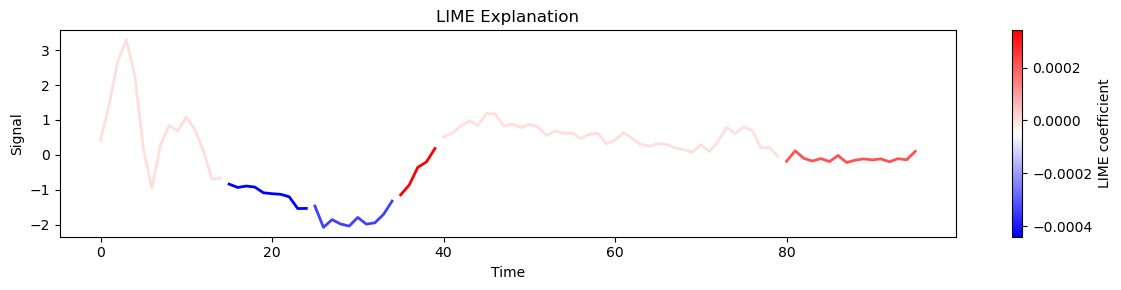

In [107]:
x, y = test_dataset[0]
boundaries = rpt.Pelt(model="rbf").fit(x.numpy()).predict(pen=3)
coefs = lime_segment(model, x, boundaries, N=100)
plot_lime_segments(x, boundaries, coefs)

**Question 5:** Generate a box plot of the LIME coefficients for the segments by repeating the LIME method on the same time series 10 times.

In [112]:
print("LIME coefficients:", coefs)

LIME coefficients: [ 9.05207534e-32 -4.40237858e-04 -3.42337649e-04  3.40884252e-04
 -5.83541811e-14  2.14412056e-04]


In [110]:
# HINT: use the matplotlib.pyplot.boxplot() method.

def lime_segment_boxplot(model, x, segment_boundaries, num_runs=10, N=100):
    all_coefs = []

    for _ in range(num_runs):
        coefs = lime_segment(model, x, segment_boundaries, N=N)
        all_coefs.append(coefs)

    all_coefs = np.array(all_coefs)

    plt.figure(figsize=(12, 6))
    plt.boxplot(all_coefs, vert=True)
    plt.xlabel("Segment index")
    plt.ylabel("LIME coefficient")
    plt.title("LIME Coefficients per Segment")
    plt.grid(True)
    plt.show()

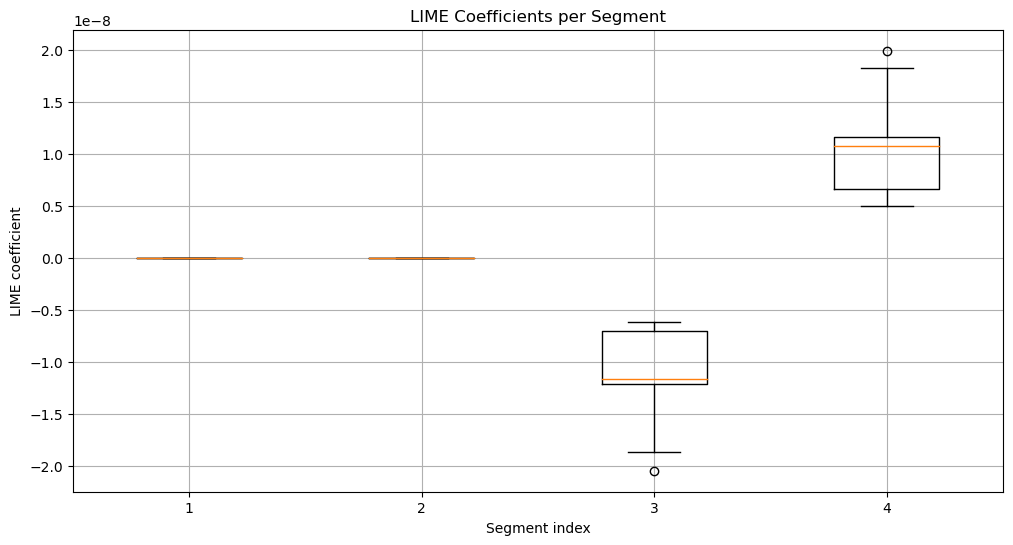

In [111]:
x, y = test_dataset[5]
boundaries = rpt.Pelt(model="rbf").fit(x.numpy()).predict(pen=3)

lime_segment_boxplot(model, x, boundaries, num_runs=10, N=100)

## Bonus: Original implementation of LIMESegment

**Question 6:**  Redo Question 1.bis using the perturbation described in lecture slide 153-154 (see the [paper](https://proceedings.mlr.press/v151/sivill22a.html) and use `torch.stft()` and `torch.istft()`).

In [121]:
def get_perturbations_upd(x, N=100, n_fft=64, hop_length=None, win_length=None):
    if isinstance(x, torch.Tensor) is False:
        x = torch.tensor(x, dtype=torch.float32)
    if x.dim() == 1:
        x = x.unsqueeze(0)

    hop_length = hop_length or n_fft // 2
    win_length = win_length or n_fft

    x_stft = torch.stft(x, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
                        return_complex=True)

    freq_bins, time_bins = x_stft.shape[-2:]

    Z = torch.randint(0, 2, (N, freq_bins, time_bins), dtype=torch.bool)

    perturbed_signals = []

    for i in range(N):
        masked_stft = x_stft.clone()
        masked_stft[0][~Z[i]] = 0
        x_recon = torch.istft(masked_stft[0], n_fft=n_fft, hop_length=hop_length, win_length=win_length,
                              length=x.shape[-1])
        perturbed_signals.append(x_recon)

    perturbed_signals = torch.stack(perturbed_signals)
    return perturbed_signals, Z

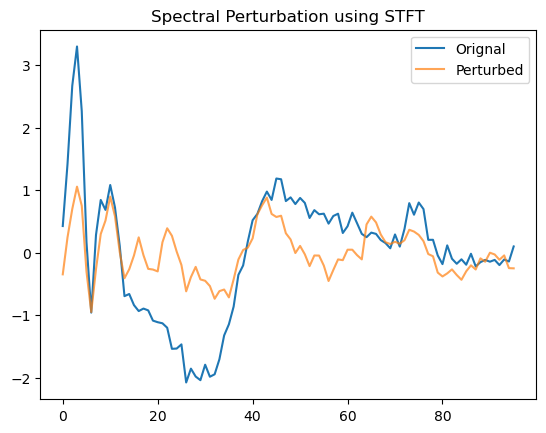

In [124]:
x, _ = test_dataset[0]
perturbed_signals, Z = get_perturbations_upd(x, N=50)

plt.plot(x.numpy(), label="Orignal")
plt.plot(perturbed_signals[0].numpy(), label="Perturbed", alpha=0.7)
plt.legend()
plt.title("Spectral Perturbation using STFT")
plt.show()

**Question 7**: Compare your LIME-based explanations to the original implementation (see the `LIMESegment` folder or [github](https://github.com/TortySivill/LIMESegment)).  